<a href="https://colab.research.google.com/github/arinjay-singh/econ3916-statistical-machine-learning/blob/main/Assignment%203%20/%20Econ_3916_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 1: Bootstrapping Non-Parametric Uncertainty

Step 1.1: The Zero-Inflated Gig Economy Tip Distribution

In [2]:
# generate data
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

Step 1.2: The Manual Bootstrap Engine

In [3]:
np.random.seed(42)

# set param values
n = len(driver_tips)
n_bootstraps = 10_000

# create list of medians
boot_medians = np.array([
    np.median(np.random.choice(driver_tips, size=n, replace=True))
    for _ in range(n_bootstraps)
])

# get lower and upper bounds
ci_lower, ci_upper = np.percentile(boot_medians, [2.5, 97.5])
print(f"Bootstrap 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Bootstrap Median of Medians: {np.median(boot_medians):.4f}")
print(f"Sample Median: {np.median(driver_tips):.4f}")

Bootstrap 95% CI: [0.2643, 1.3636]
Bootstrap Median of Medians: 0.7553
Sample Median: 0.7553


The Confidence Interval of [0.2643, 1.3636] is notably right-skewed as the upper half-width is approximately 0.61 while the lower half-width is only 0.49. The exponential component pulls bootstrap medians upward more aggressively than downward, so the sampling distribution of the median itself inherits that skew as well. A standard parametric CI would force symmetry by definition at +/- 1.96 standard deviations around the center, misrepresenting the distribution. On the other hand, the bootstrap lets the empirical resampling distribution determine the CI.

## Phase 2: Falsification in Logistics A/B Testing

Step 2.1: The Algorithmic Routing Crash

In [4]:
np.random.seed(42)

# create control with specified params
control = np.random.normal(loc=35, scale=5, size=500)
# create treatment with specified params
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

# compute the difference in means
observed_diff = np.mean(control) - np.mean(treatment)

# display results
print(f"Control Mean: {np.mean(control):.4f}")
print(f"Treatment Mean: {np.mean(treatment):.4f}")
print(f"Observed Difference (Control - Treatment): {observed_diff:.4f}")

Control Mean: 35.0342
Treatment Mean: 32.7692
Observed Difference (Control - Treatment): 2.2650


Step 2.2: The Exact Non-Parametric Permutation

In [6]:
np.random.seed(42)

# concatenate arrays
combined = np.concatenate([control, treatment])

# set num of permutations
n_permutations = 5_000

# compute the difference in means for each iteration
perm_diffs = np.array([
    np.mean(shuffled[:500]) - np.mean(shuffled[500:])
    for _ in range(n_permutations)
    for shuffled in [np.random.permutation(combined)]
])

# compute the p-value as the proportion of sampled mean differences
# that were equal to or more extreme than observed difference
p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

# display results
print(f"Observed Difference: {observed_diff:.4f}")
print(f"Empirical P-value: {p_value:.4f}")

Observed Difference: 2.2650
Empirical P-value: 0.0004


## Phase 3: Causal Control and the Mitigation of Selection Bias

Step 3.1: The Loyalty Program Paradox

In [8]:
import pandas as pd

df = pd.read_csv('swiftcart_loyalty.csv')
df.head()

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227


In [11]:
sdo = df[df['subscriber']==1]['post_spend'].mean() - df[df['subscriber']==0]['post_spend'].mean()

print(f"Subscriber Mean Post-Treatment Spending: {df[df['subscriber']==1]['post_spend'].mean():.4f}")
print(f"Non-Subscriber Mean Post-Treatment Spending: {df[df['subscriber']==0]['post_spend'].mean():.4f}")
print(f"Naive SDO: {sdo:.4f}")

Subscriber Mean Post-Treatment Spending: 74.0436
Non-Subscriber Mean Post-Treatment Spending: 56.4729
Naive SDO: 17.5707


Step 3.2: Propensity Score Matching (PSM) Architecture

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd

In [15]:
# extract features and target variable
X = df[['pre_spend', 'account_age', 'support_tickets']]
D = df['subscriber']

# init and fit model
lr = LogisticRegression()
lr.fit(X, D)

# predict propensity scores
df['propensity_score'] = lr.predict_proba(X)[:, 1]

In [16]:
# create treated and control dataframes
treated = df[df['subscriber'] == 1].copy()
control = df[df['subscriber'] == 0].copy()

# init and fit model
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

# compute nearest non-subscribers to each subscriber
distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].copy()

In [18]:
# compute average treatment effect on treated
att = np.mean(treated['post_spend'].values - matched_control['post_spend'].values)

print(f"Naive SDO:  {sdo:.4f}")
print(f"ATT (PSM):  {att:.4f}")
print(f"Difference: {sdo - att:.4f}")

Naive SDO:  17.5707
ATT:  9.9139
Difference: 7.6568


The naive Simple Difference in Means (17.5707) overstates the treatment effect because it doesn't differentiate the program's causal impact from the pre-existing spending trends of users who would have spent more regardless. In contrast, Propensity Score Matching (9.9139) isolates this by matching each subscriber with a non-subscriber that most closely resembles their pre-treatment covariates (pre-spend, account age, support tickets). Therefore the only remaining variation is attributable to SwiftPass itself. The marketing team should be using the latter statistic to prevent an inflated interpretation of the program's effectiveness.

## Phase 4: AI Expansion (The Co-Pilot Era)

Task 4.1: The "Love Plot" Visualization Directive

In [20]:
# df_unmatched is just the full original dataframe
df_unmatched = df.copy()

# df_matched is the treated rows + their matched control rows stacked
df_matched = pd.concat([treated, matched_control], ignore_index=True)

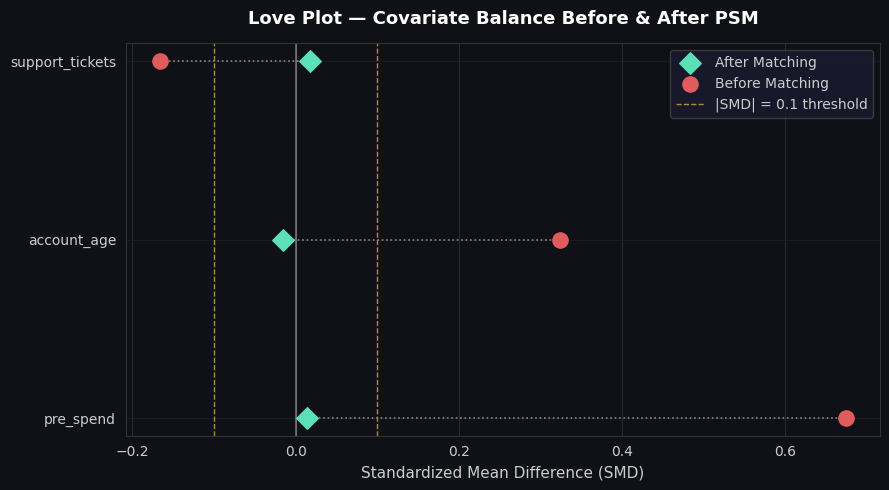

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

def compute_smd(df, covariates, treatment_col='subscriber'):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    smds = {}
    for cov in covariates:
        mean_t = treated[cov].mean()
        mean_c = control[cov].mean()
        # Pooled std using treated variance as reference (Austin 2009 convention)
        pooled_std = np.sqrt((treated[cov].var() + control[cov].var()) / 2)
        smds[cov] = (mean_t - mean_c) / pooled_std
    return smds

covariates = ['pre_spend', 'account_age', 'support_tickets']

smd_before = compute_smd(df_unmatched, covariates)
smd_after  = compute_smd(df_matched,   covariates)

plot_df = pd.DataFrame({
    'Covariate': covariates * 2,
    'SMD':       list(smd_before.values()) + list(smd_after.values()),
    'Sample':    ['Before Matching'] * len(covariates) + ['After Matching'] * len(covariates)
})

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#0f1117')

palette = {'Before Matching': '#e05c5c', 'After Matching': '#5ce0b8'}
markers = {'Before Matching': 'o', 'After Matching': 'D'}

for sample, grp in plot_df.groupby('Sample'):
    ax.scatter(grp['SMD'], grp['Covariate'],
               color=palette[sample], marker=markers[sample],
               s=120, zorder=5, label=sample)

# Reference lines
ax.axvline(0,    color='white',  lw=1.2, ls='-',  alpha=0.4)
ax.axvline(0.1,  color='#f0c040', lw=1,  ls='--', alpha=0.7)
ax.axvline(-0.1, color='#f0c040', lw=1,  ls='--', alpha=0.7, label='|SMD| = 0.1 threshold')

# Connect before/after per covariate
for cov in covariates:
    x_before = smd_before[cov]
    x_after  = smd_after[cov]
    ax.plot([x_before, x_after], [cov, cov],
            color='#888', lw=1.2, ls=':', zorder=3)

# ── Labels & formatting ────────────────────────────────────────────────────
ax.set_xlabel('Standardized Mean Difference (SMD)', color='#cccccc', fontsize=11)
ax.set_title('Love Plot — Covariate Balance Before & After PSM',
             color='white', fontsize=13, fontweight='bold', pad=14)

ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333')

ax.xaxis.label.set_color('#cccccc')
ax.yaxis.label.set_color('#cccccc')
plt.setp(ax.get_yticklabels(), color='#cccccc')
plt.setp(ax.get_xticklabels(), color='#cccccc')
ax.grid(axis='x', color='#2a2a2a', linewidth=0.8)
ax.grid(axis='y', color='#222', linewidth=0.5)

legend = ax.legend(facecolor='#1a1a2e', edgecolor='#444',
                   labelcolor='#cccccc', fontsize=10)
plt.tight_layout()
plt.savefig('love_plot.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()